In [67]:
import pandas as pd

df = pd.read_excel('/content/Datathoncleaned_data.xlsx')
df.head()

,Name,Account,PK,Offst.acct,Assignment,Pstng Date,Amount in USD,Posting Period,Category Index,Weekly_Period,Flow_Code
0,TW10,19500100,50,19500102,200021,2025-08-01,-13.85,2025-08,1,2025-08-W1,1
1,TW10,19500100,50,19500102,200021,2025-08-01,-15.81,2025-08,1,2025-08-W1,1
2,TW10,19500100,50,19500102,200021,2025-08-01,-14.99,2025-08,1,2025-08-W1,1
3,TW10,19500100,50,19500102,200021,2025-08-01,-11.90,2025-08,1,2025-08-W1,1
4,TW10,19500100,50,19500102,200021,2025-08-01,-15.16,2025-08,1,2025-08-W1,1


In [68]:
total_amount_usd = df['Amount in USD'].sum()
print(f"Total Amount in USD: ${total_amount_usd:,.2f}")

Total Amount in USD: $-3,919,686.45


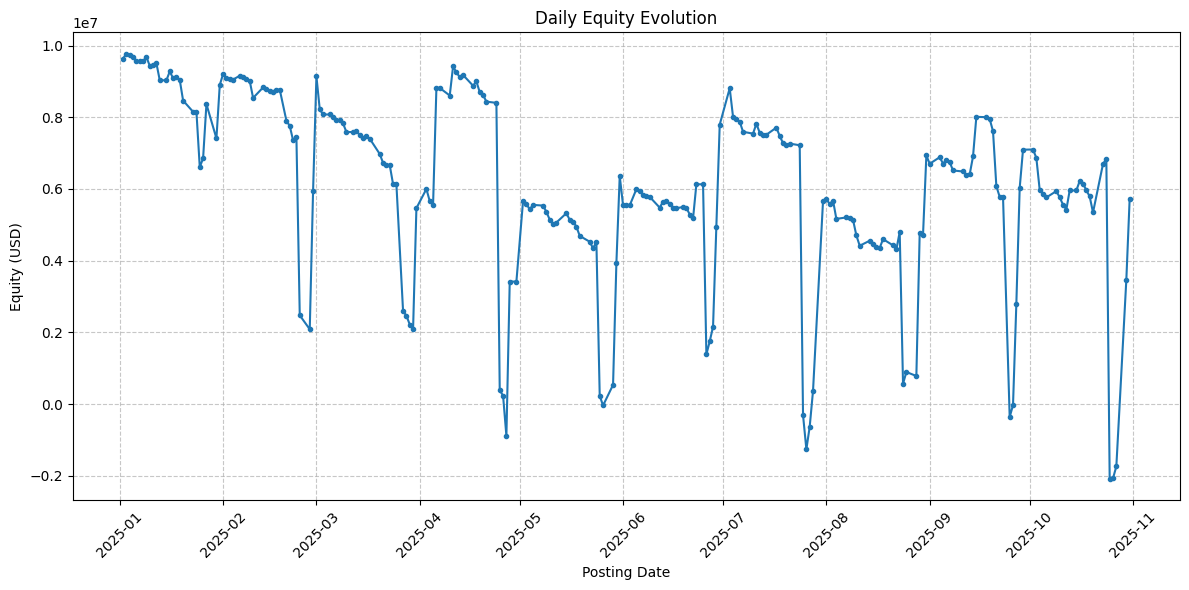

In [69]:
daily_net_flow = df.groupby('Pstng Date')['Amount in USD'].sum().reset_index()

initial_equity = 9654990.29 - 2247.01
daily_net_flow['Equity'] = initial_equity + daily_net_flow['Amount in USD'].cumsum()

plt.figure(figsize=(12, 6))
plt.plot(daily_net_flow['Pstng Date'], daily_net_flow['Equity'], marker='.', linestyle='-')
plt.title('Daily Equity Evolution')
plt.xlabel('Posting Date')
plt.ylabel('Equity (USD)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [70]:
min_cash = daily_net_flow['Equity'].min()
current_cash = daily_net_flow['Equity'].iloc[-1]

avg_daily_flow = daily_net_flow['Amount in USD'].mean()

gross_inflow = daily_net_flow[daily_net_flow['Amount in USD'] > 0]['Amount in USD'].sum()
gross_outflow = daily_net_flow[daily_net_flow['Amount in USD'] < 0]['Amount in USD'].sum()
profit_factor = gross_inflow / abs(gross_outflow) if gross_outflow != 0 else float('inf')

if avg_daily_flow < 0:
    runway_days = current_cash / abs(avg_daily_flow)
    runway_str = f"{runway_days:.1f} Days"
else:
    runway_str = "Infinite (Positive Cash Flow)"

print(f"--- Operational Health ---")
print(f"Current Cash:      ${current_cash:,.2f}")
print(f"Lowest Cash Point: ${min_cash:,.2f}")
print(f"Avg Daily Flow:    ${avg_daily_flow:,.2f}")
print(f"Profit Factor:     {profit_factor:.2f} (Target > 1.0)")
print(f"Runway:            {runway_str}")

--- Operational Health ---
Current Cash:      $5,733,056.83
Lowest Cash Point: $-2,085,768.11
Avg Daily Flow:    $-17,042.11
Profit Factor:     0.95 (Target > 1.0)
Runway:            336.4 Days


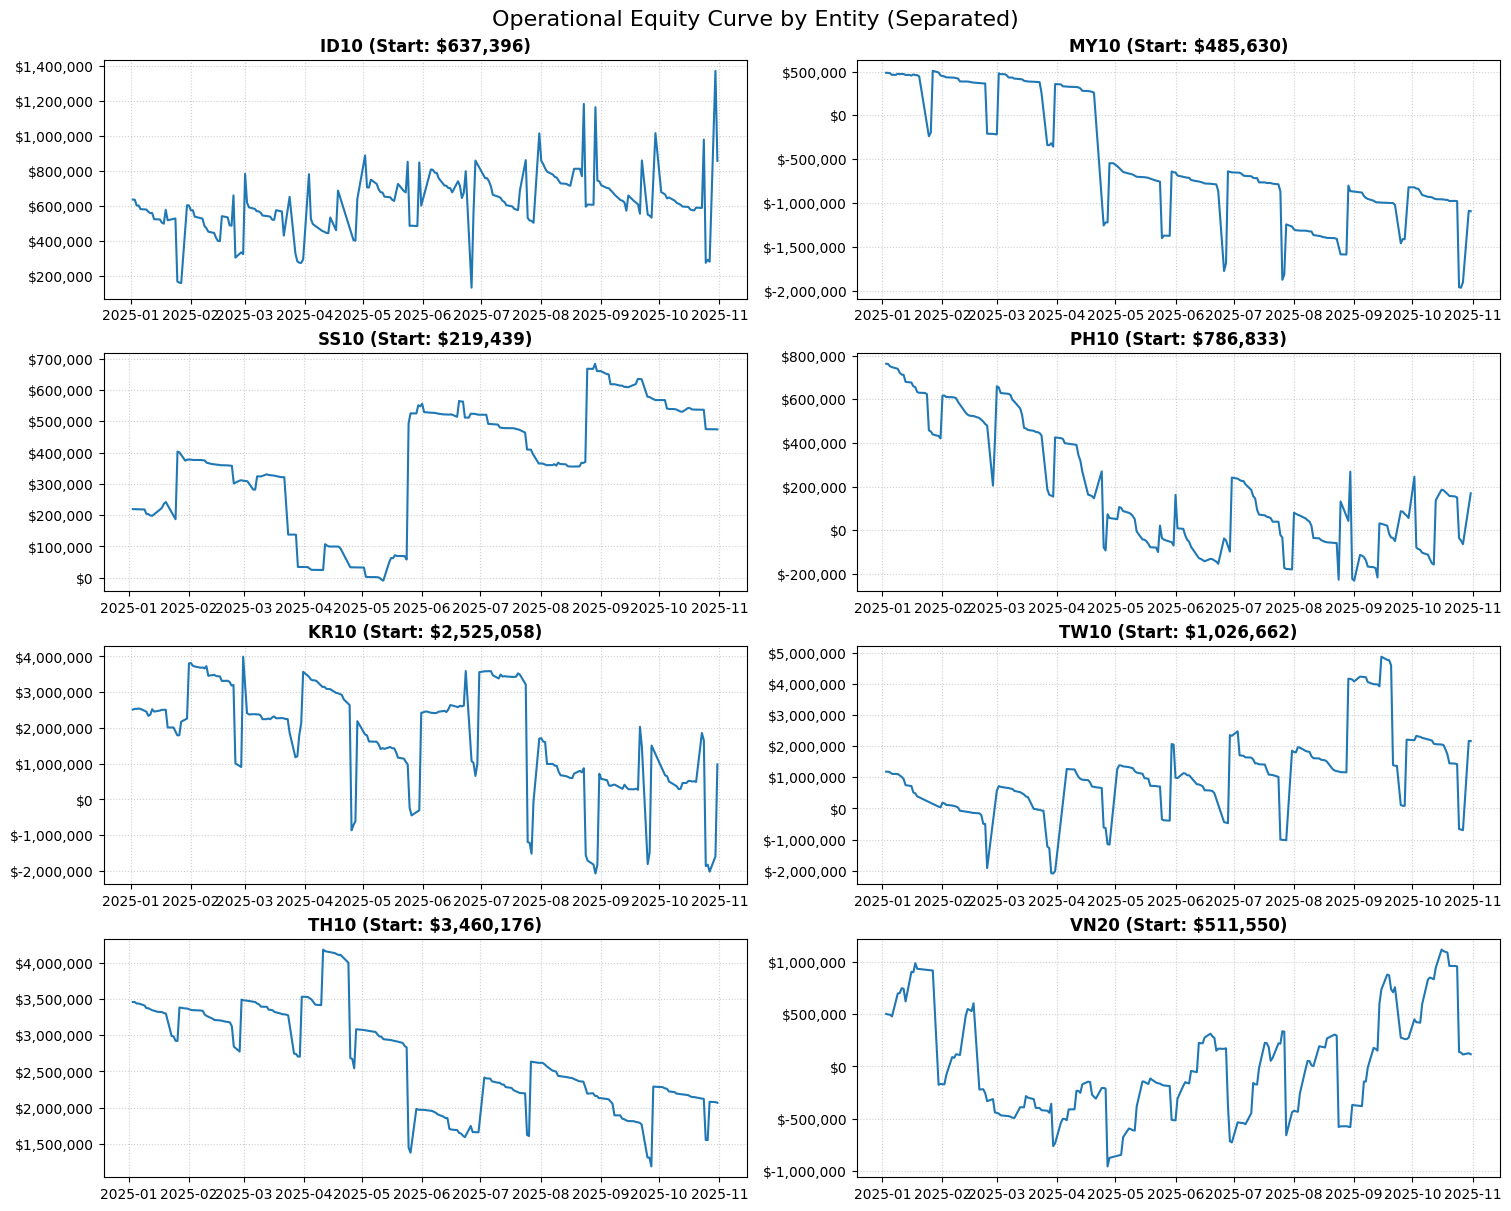

In [71]:
import matplotlib.pyplot as plt
import math

starting_balances = {
    'ID10': 639643.01-2247.01,
    'MY10': 485629.61,
    'SS10': 219439.04,
    'PH10': 786832.65,
    'KR10': 2525058.35,
    'TW10': 1026662.22,
    'TH10': 3460175.61,
    'VN20': 511549.80
}

entities = list(starting_balances.keys())
n_cols = 2
n_rows = math.ceil(len(entities) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 12), constrained_layout=True)
axes = axes.flatten()

for i, (name, start_bal) in enumerate(starting_balances.items()):
    ax = axes[i]
    entity_data = df[df['Name'] == name].copy()

    if not entity_data.empty:
        daily_flow = entity_data.groupby('Pstng Date')['Amount in USD'].sum().reset_index()
        daily_flow = daily_flow.sort_values('Pstng Date')

        daily_flow['Equity'] = start_bal + daily_flow['Amount in USD'].cumsum()

        ax.plot(daily_flow['Pstng Date'], daily_flow['Equity'], color='tab:blue', linewidth=1.5)

        ax.set_title(f"{name} (Start: ${start_bal:,.0f})", fontweight='bold')
        ax.grid(True, linestyle=':', alpha=0.6)

        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

    else:
        ax.text(0.5, 0.5, 'No Data Available', ha='center', transform=ax.transAxes)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Operational Equity Curve by Entity (Separated)", fontsize=16)
plt.show()

In [72]:
starting_balances = {
    'ID10': 639643.01-2247.01,
    'MY10': 485629.61,
    'SS10': 219439.04,
    'PH10': 786832.65,
    'KR10': 2525058.35,
    'TW10': 1026662.22,
    'TH10': 3460175.61,
    'VN20': 511549.80
}

results = []

for name, start_bal in starting_balances.items():
    entity_df = df[df['Name'] == name].copy()

    if not entity_df.empty:
        daily_agg = entity_df.groupby('Pstng Date')['Amount in USD'].sum().reset_index()
        daily_agg = daily_agg.sort_values('Pstng Date')

        daily_agg['Equity'] = start_bal + daily_agg['Amount in USD'].cumsum()

        current_cash = daily_agg['Equity'].iloc[-1]
        lowest_cash = daily_agg['Equity'].min()
        avg_daily_flow = daily_agg['Amount in USD'].mean()

        gross_inflow = daily_agg[daily_agg['Amount in USD'] > 0]['Amount in USD'].sum()
        gross_outflow = daily_agg[daily_agg['Amount in USD'] < 0]['Amount in USD'].sum()
        profit_factor = gross_inflow / abs(gross_outflow) if gross_outflow != 0 else float('inf')

        if avg_daily_flow < 0:
            runway = current_cash / abs(avg_daily_flow)
            runway_str = f"{runway:.1f} Days"
        else:
            runway_str = "Infinite (+Flow)"

        results.append({
            'Entity': name,
            'Current Cash': current_cash,
            'Lowest Point': lowest_cash,
            'Avg Daily Flow': avg_daily_flow,
            'Profit Factor': profit_factor,
            'Runway': runway_str
        })

summary_df = pd.DataFrame(results)

pd.options.display.float_format = '{:,.2f}'.format
print(summary_df)

  Entity  Current Cash  Lowest Point  Avg Daily Flow  Profit Factor  \
0   ID10    855,515.21    130,546.55        1,096.08           1.02   
1   MY10 -1,094,169.48 -1,966,447.93       -7,668.93           0.83   
2   SS10    474,042.83     -9,190.17        1,347.11           1.22   
3   PH10    169,231.40   -230,817.13       -2,998.06           0.87   
4   KR10    982,029.73 -2,071,792.52       -7,418.41           0.96   
5   TW10  2,163,936.72 -2,092,813.52        5,547.68           1.04   
6   TH10  2,065,701.36  1,185,118.57       -6,903.34           0.84   
7   VN20    116,769.06   -954,189.36       -1,916.41           0.96   

             Runway  
0  Infinite (+Flow)  
1       -142.7 Days  
2  Infinite (+Flow)  
3         56.4 Days  
4        132.4 Days  
5  Infinite (+Flow)  
6        299.2 Days  
7         60.9 Days  


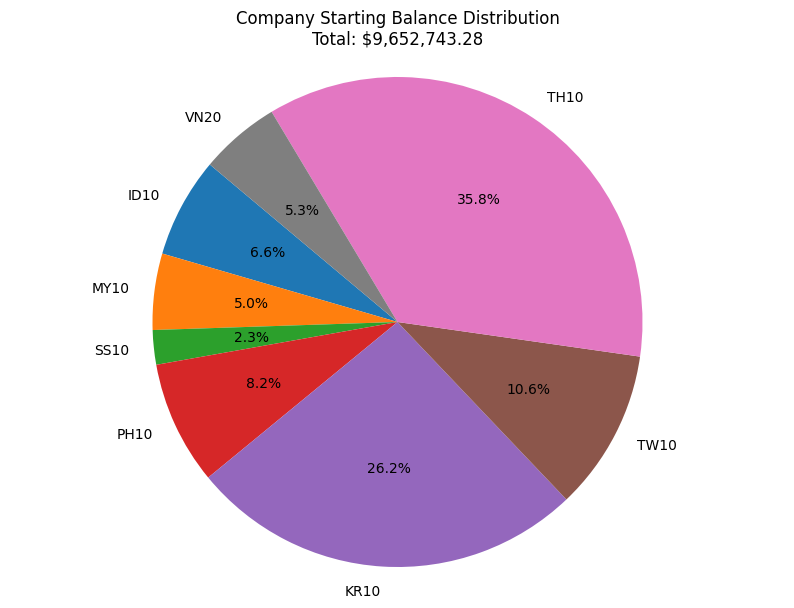

In [73]:
import matplotlib.pyplot as plt

starting_balances = {
    'ID10': 639643.01 - 2247.01,
    'MY10': 485629.61,
    'SS10': 219439.04,
    'PH10': 786832.65,
    'KR10': 2525058.35,
    'TW10': 1026662.22,
    'TH10': 3460175.61,
    'VN20': 511549.80
}

labels = list(starting_balances.keys())
sizes = list(starting_balances.values())
total_balance = sum(sizes)

plt.figure(figsize=(10, 7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title(f'Company Starting Balance Distribution\nTotal: ${total_balance:,.2f}')
plt.axis('equal')
plt.show()

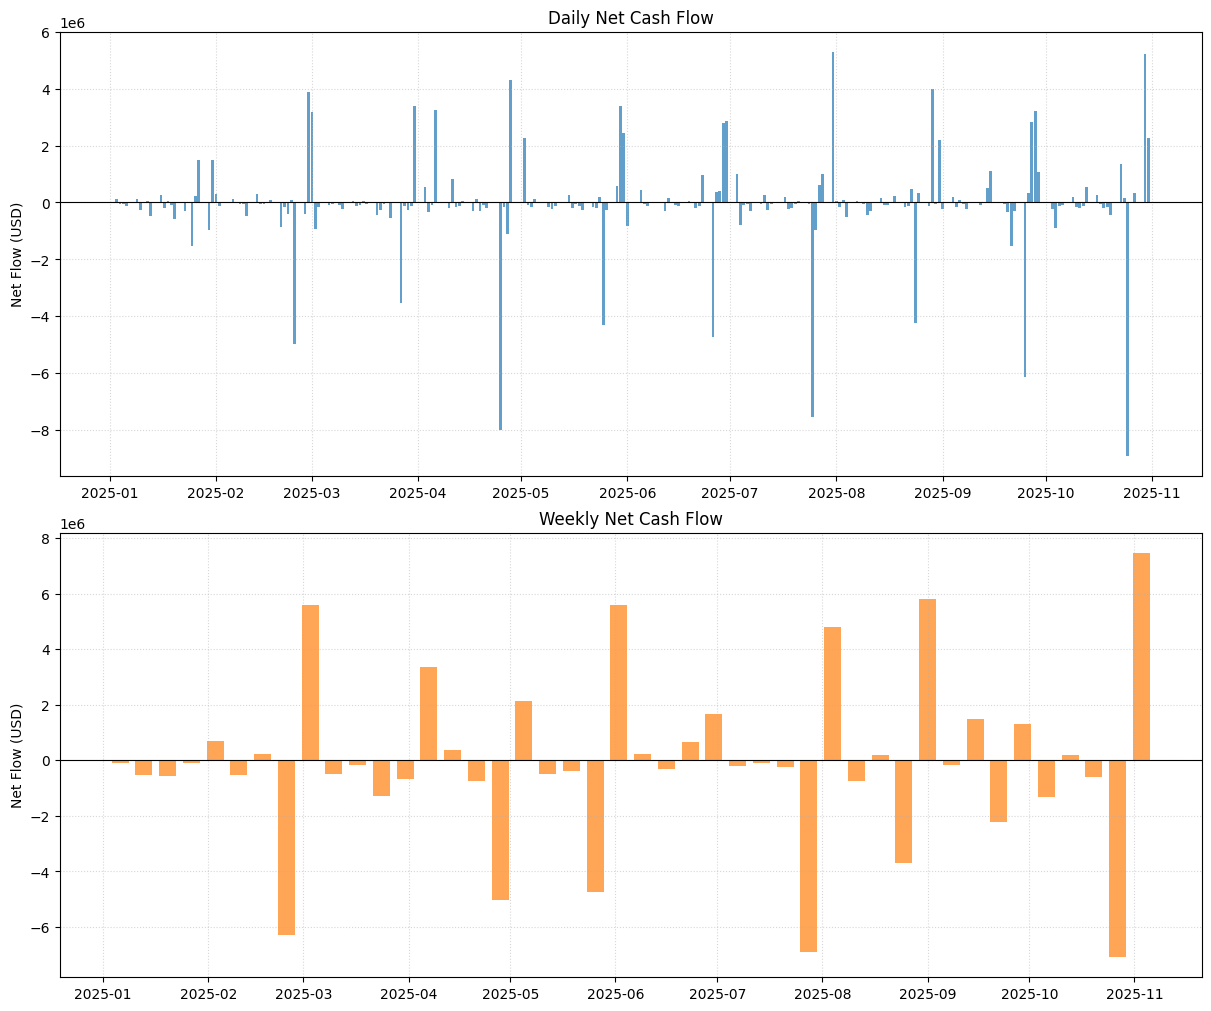

In [74]:
df['Pstng Date'] = pd.to_datetime(df['Pstng Date'])

daily_net_flow = df.groupby('Pstng Date')['Amount in USD'].sum()

weekly_net_flow = df.set_index('Pstng Date')['Amount in USD'].resample('W-MON').sum()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), constrained_layout=True)

ax1.bar(daily_net_flow.index, daily_net_flow, color='tab:blue', alpha=0.7)
ax1.set_title('Daily Net Cash Flow')
ax1.set_ylabel('Net Flow (USD)')
ax1.axhline(0, color='black', linewidth=0.8)
ax1.grid(True, linestyle=':', alpha=0.5)

ax2.bar(weekly_net_flow.index, weekly_net_flow, color='tab:orange', alpha=0.7, width=5)
ax2.set_title('Weekly Net Cash Flow')
ax2.set_ylabel('Net Flow (USD)')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.grid(True, linestyle=':', alpha=0.5)

plt.show()

In [76]:
daily_net_flow = df.groupby('Pstng Date')['Amount in USD'].sum().reset_index()
daily_net_flow['delta_cashflow'] = daily_net_flow['Amount in USD'].diff()
daily_net_flow.head()

,Pstng Date,Amount in USD,delta_cashflow
0,2025-01-02,"-13,605.12",NaN
1,2025-01-03,"137,048.39","150,653.51"
2,2025-01-04,"-43,476.03","-180,524.42"
3,2025-01-05,"-48,472.97","-4,996.93"
4,2025-01-06,"-117,887.39","-69,414.42"


In [77]:
delta_cashflow_mean = daily_net_flow['delta_cashflow'].mean()
delta_cashflow_std = daily_net_flow['delta_cashflow'].std()

big_rise_threshold = delta_cashflow_mean + (2 * delta_cashflow_std)
big_drop_threshold = delta_cashflow_mean - (2 * delta_cashflow_std)

daily_net_flow['is_big_rise'] = daily_net_flow['delta_cashflow'] > big_rise_threshold
daily_net_flow['is_big_drop'] = daily_net_flow['delta_cashflow'] < big_drop_threshold

print(f"Mean of daily cashflow change: ${delta_cashflow_mean:,.2f}")
print(f"Standard deviation of daily cashflow change: ${delta_cashflow_std:,.2f}")
print(f"Big rise threshold: ${big_rise_threshold:,.2f}")
print(f"Big drop threshold: ${big_drop_threshold:,.2f}")

daily_net_flow.head()

Mean of daily cashflow change: $9,941.11
Standard deviation of daily cashflow change: $2,117,572.08
Big rise threshold: $4,245,085.27
Big drop threshold: $-4,225,203.06


,Pstng Date,Amount in USD,delta_cashflow,is_big_rise,is_big_drop
0,2025-01-02,"-13,605.12",NaN,False,False
1,2025-01-03,"137,048.39","150,653.51",False,False
2,2025-01-04,"-43,476.03","-180,524.42",False,False
3,2025-01-05,"-48,472.97","-4,996.93",False,False
4,2025-01-06,"-117,887.39","-69,414.42",False,False


In [78]:
significant_event_dates = daily_net_flow[
    daily_net_flow['is_big_rise'] | daily_net_flow['is_big_drop']
]['Pstng Date'].tolist()

df_significant_events = df[df['Pstng Date'].isin(significant_event_dates)].copy()

print(f"Number of significant event dates identified: {len(significant_event_dates)}")
print(f"Number of transactions on significant event dates: {len(df_significant_events)}")
print("First 5 transactions on significant event dates:")
print(df_significant_events.head())

Number of significant event dates identified: 21
Number of transactions on significant event dates: 8135
First 5 transactions on significant event dates:
   Name   Account  PK  Offst.acct Assignment Pstng Date  Amount in USD  \
0  TW10  19500100  50    19500102     200021 2025-08-01         -13.85   
1  TW10  19500100  50    19500102     200021 2025-08-01         -15.81   
2  TW10  19500100  50    19500102     200021 2025-08-01         -14.99   
3  TW10  19500100  50    19500102     200021 2025-08-01         -11.90   
4  TW10  19500100  50    19500102     200021 2025-08-01         -15.16   

  Posting Period  Category Index Weekly_Period  Flow_Code  
0        2025-08               1    2025-08-W1          1  
1        2025-08               1    2025-08-W1          1  
2        2025-08               1    2025-08-W1          1  
3        2025-08               1    2025-08-W1          1  
4        2025-08               1    2025-08-W1          1  


/tmp/ipython-input-3114478002.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=name_contributions.index, y=name_contributions.values, ax=axes[0], palette='viridis')
/tmp/ipython-input-3114478002.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=offset_account_contributions.index, y=offset_account_contributions.values, ax=axes[1], palette='magma')


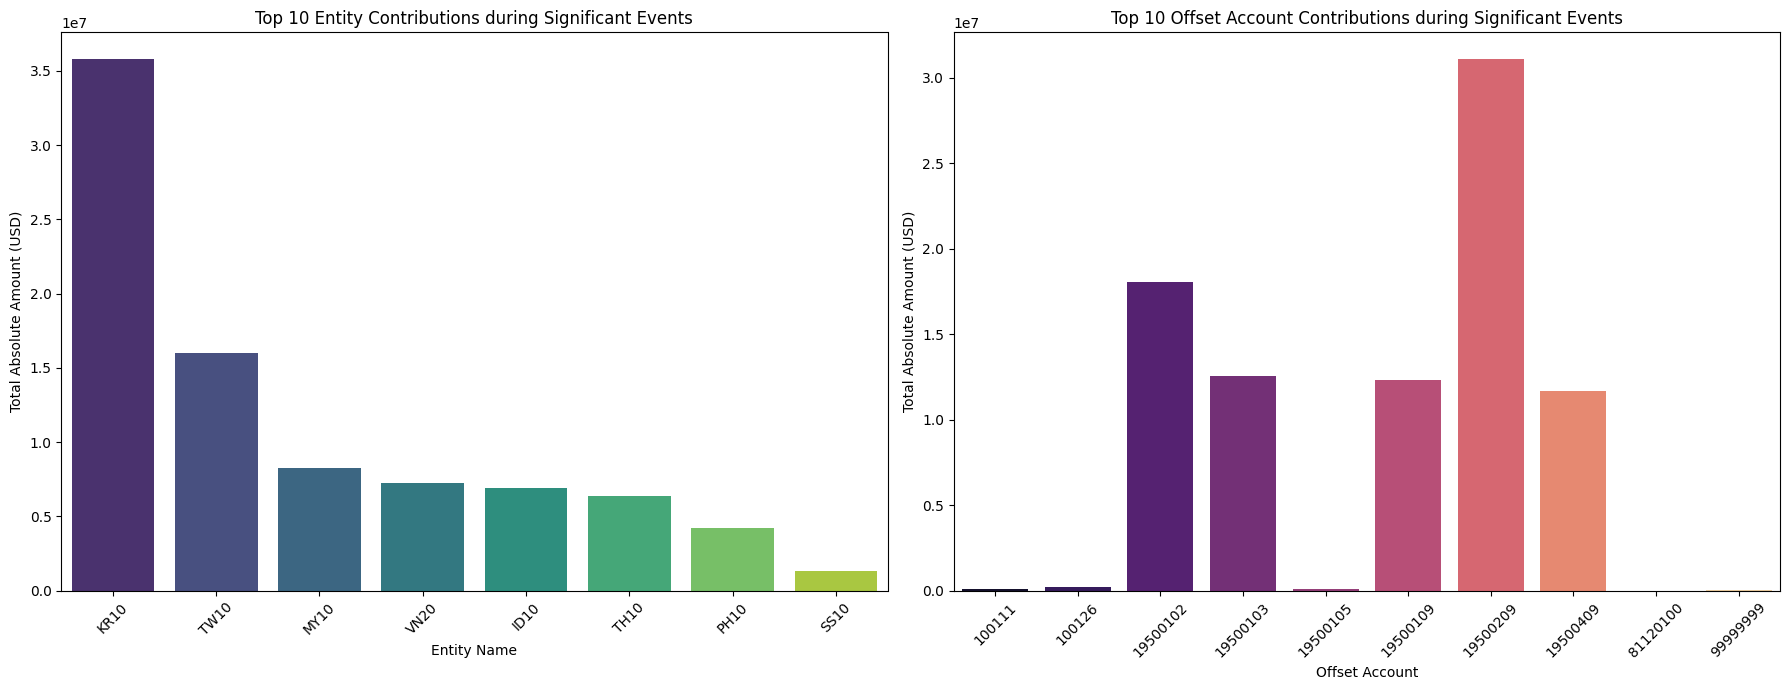

Top 10 Entity Contributions during Significant Events:
Name
KR10   35,798,640.98
TW10   16,024,964.62
MY10    8,232,588.36
VN20    7,238,582.27
ID10    6,937,406.19
TH10    6,397,296.91
PH10    4,212,318.10
SS10    1,337,353.73
Name: Amount in USD, dtype: float64

Top 10 Offset Account Contributions during Significant Events:
Offst.acct
19500209   31,108,216.45
19500102   18,071,314.02
19500103   12,551,943.54
19500109   12,294,300.15
19500409   11,701,520.07
100126        200,756.43
100111        118,589.75
19500105      104,929.43
99999999       18,293.93
81120100        5,105.79
Name: Amount in USD, dtype: float64


In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

name_contributions = df_significant_events.groupby('Name')['Amount in USD'].apply(lambda x: x.abs().sum()).sort_values(ascending=False).head(10)

offset_account_contributions = df_significant_events.groupby('Offst.acct')['Amount in USD'].apply(lambda x: x.abs().sum()).sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(x=name_contributions.index, y=name_contributions.values, ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Entity Contributions during Significant Events')
axes[0].set_xlabel('Entity Name')
axes[0].set_ylabel('Total Absolute Amount (USD)')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x=offset_account_contributions.index, y=offset_account_contributions.values, ax=axes[1], palette='magma')
axes[1].set_title('Top 10 Offset Account Contributions during Significant Events')
axes[1].set_xlabel('Offset Account')
axes[1].set_ylabel('Total Absolute Amount (USD)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Top 10 Entity Contributions during Significant Events:")
print(name_contributions)
print("\nTop 10 Offset Account Contributions during Significant Events:")
print(offset_account_contributions)


In [80]:
daily_net_flow['delta_cashflow_lag1'] = daily_net_flow['delta_cashflow'].shift(1)

lagged_correlation = daily_net_flow['delta_cashflow'].corr(daily_net_flow['delta_cashflow_lag1'])

print(f"Lagged correlation (delta_cashflow vs delta_cashflow_lag1): {lagged_correlation:.4f}")

Lagged correlation (delta_cashflow vs delta_cashflow_lag1): -0.4261


In [81]:
for k in range(1,6):
    print(k, daily_net_flow['delta_cashflow'].corr(
        daily_net_flow['delta_cashflow'].shift(k)
    ))

1 -0.4261311612831456
2 0.050365206258102965
3 -0.1988546170109085
4 0.045828933155737016
5 -0.0008184969555009839


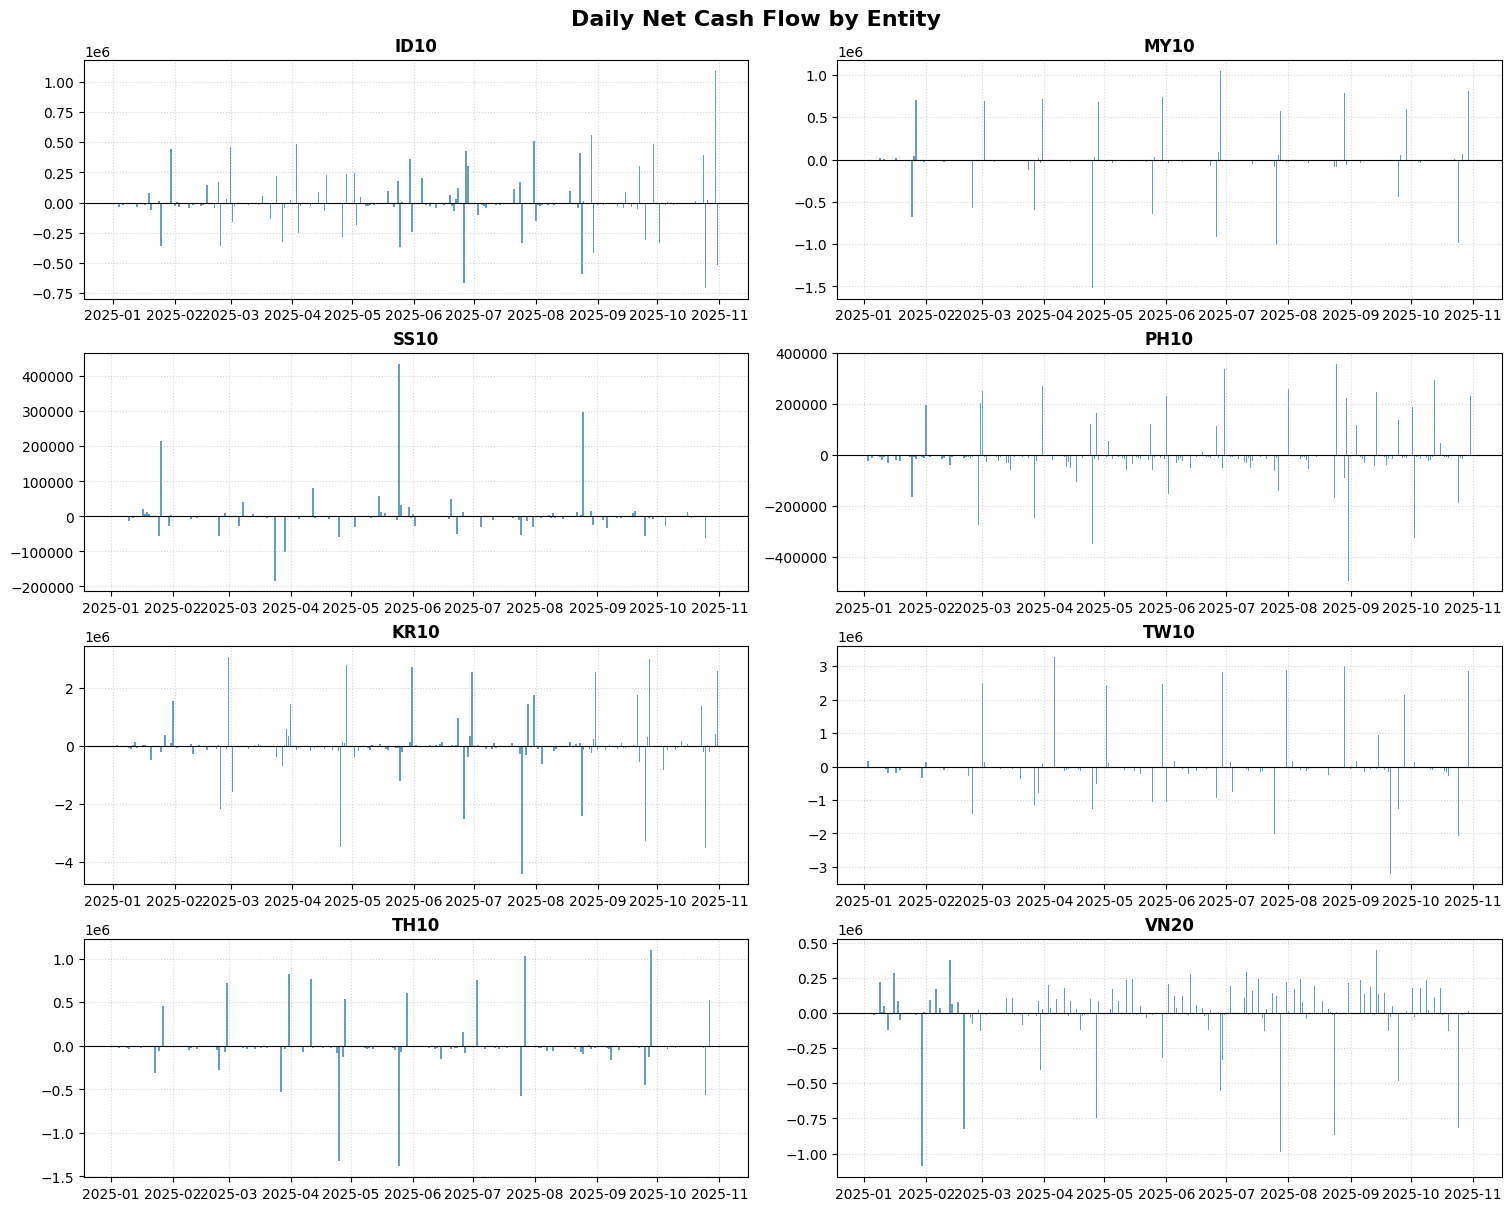

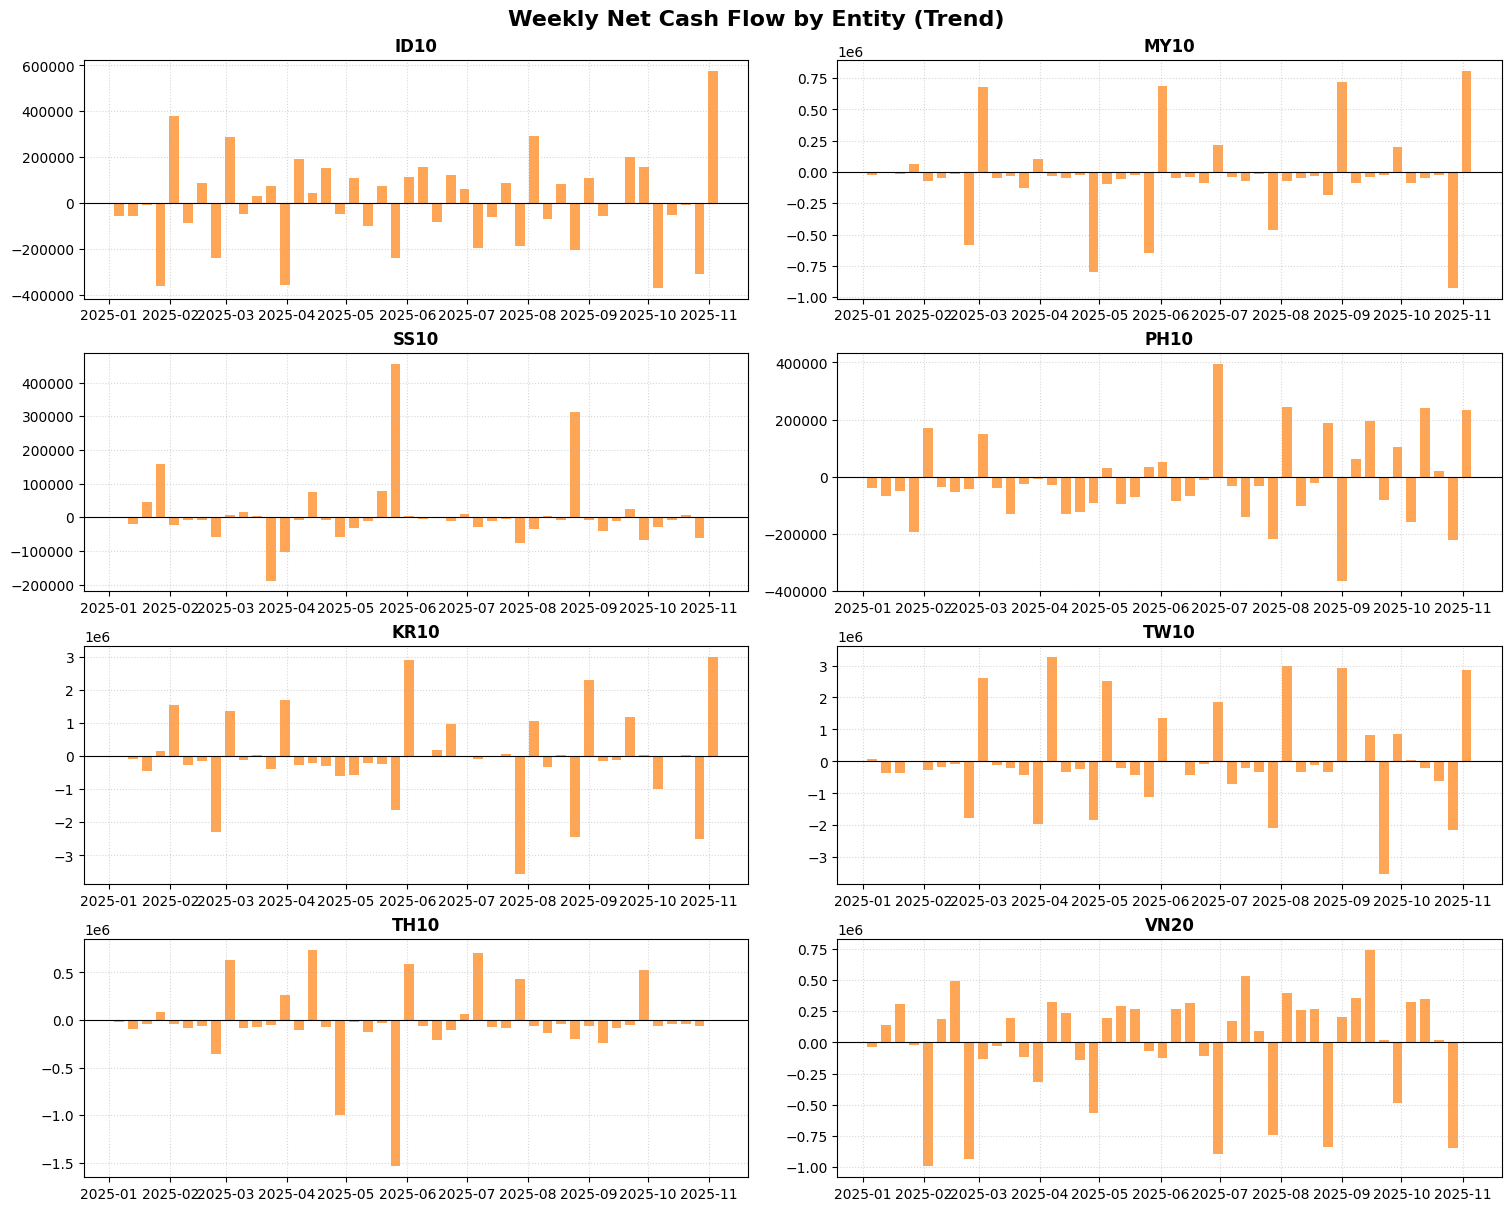

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import math

# 1. Setup Data
entities = ['ID10', 'MY10', 'SS10', 'PH10', 'KR10', 'TW10', 'TH10', 'VN20']
df['Pstng Date'] = pd.to_datetime(df['Pstng Date'])

# 2. Configuration for Subplots (4 rows x 2 columns)
n_cols = 2
n_rows = math.ceil(len(entities) / n_cols)

# --- FIGURE 1: DAILY NET FLOW ---
fig1, axes1 = plt.subplots(n_rows, n_cols, figsize=(15, 12), constrained_layout=True)
axes1 = axes1.flatten()
fig1.suptitle("Daily Net Cash Flow by Entity", fontsize=16, fontweight='bold')

for i, name in enumerate(entities):
    ax = axes1[i]
    entity_data = df[df['Name'] == name].copy()

    if not entity_data.empty:
        # Daily Aggregation
        daily = entity_data.groupby('Pstng Date')['Amount in USD'].sum()

        # Plot Bar
        ax.bar(daily.index, daily, color='tab:blue', alpha=0.7)
        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_title(name, fontweight='bold')
        ax.grid(True, linestyle=':', alpha=0.5)
    else:
        ax.text(0.5, 0.5, 'No Data', ha='center', transform=ax.transAxes)

# --- FIGURE 2: WEEKLY NET FLOW ---
fig2, axes2 = plt.subplots(n_rows, n_cols, figsize=(15, 12), constrained_layout=True)
axes2 = axes2.flatten()
fig2.suptitle("Weekly Net Cash Flow by Entity (Trend)", fontsize=16, fontweight='bold')

for i, name in enumerate(entities):
    ax = axes2[i]
    entity_data = df[df['Name'] == name].copy()

    if not entity_data.empty:
        # Weekly Aggregation (Resample)
        weekly = entity_data.set_index('Pstng Date')['Amount in USD'].resample('W-MON').sum()

        # Plot Bar (Width increased for visibility on weekly scale)
        ax.bar(weekly.index, weekly, color='tab:orange', alpha=0.7, width=5)
        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_title(name, fontweight='bold')
        ax.grid(True, linestyle=':', alpha=0.5)
    else:
        ax.text(0.5, 0.5, 'No Data', ha='center', transform=ax.transAxes)

plt.show()

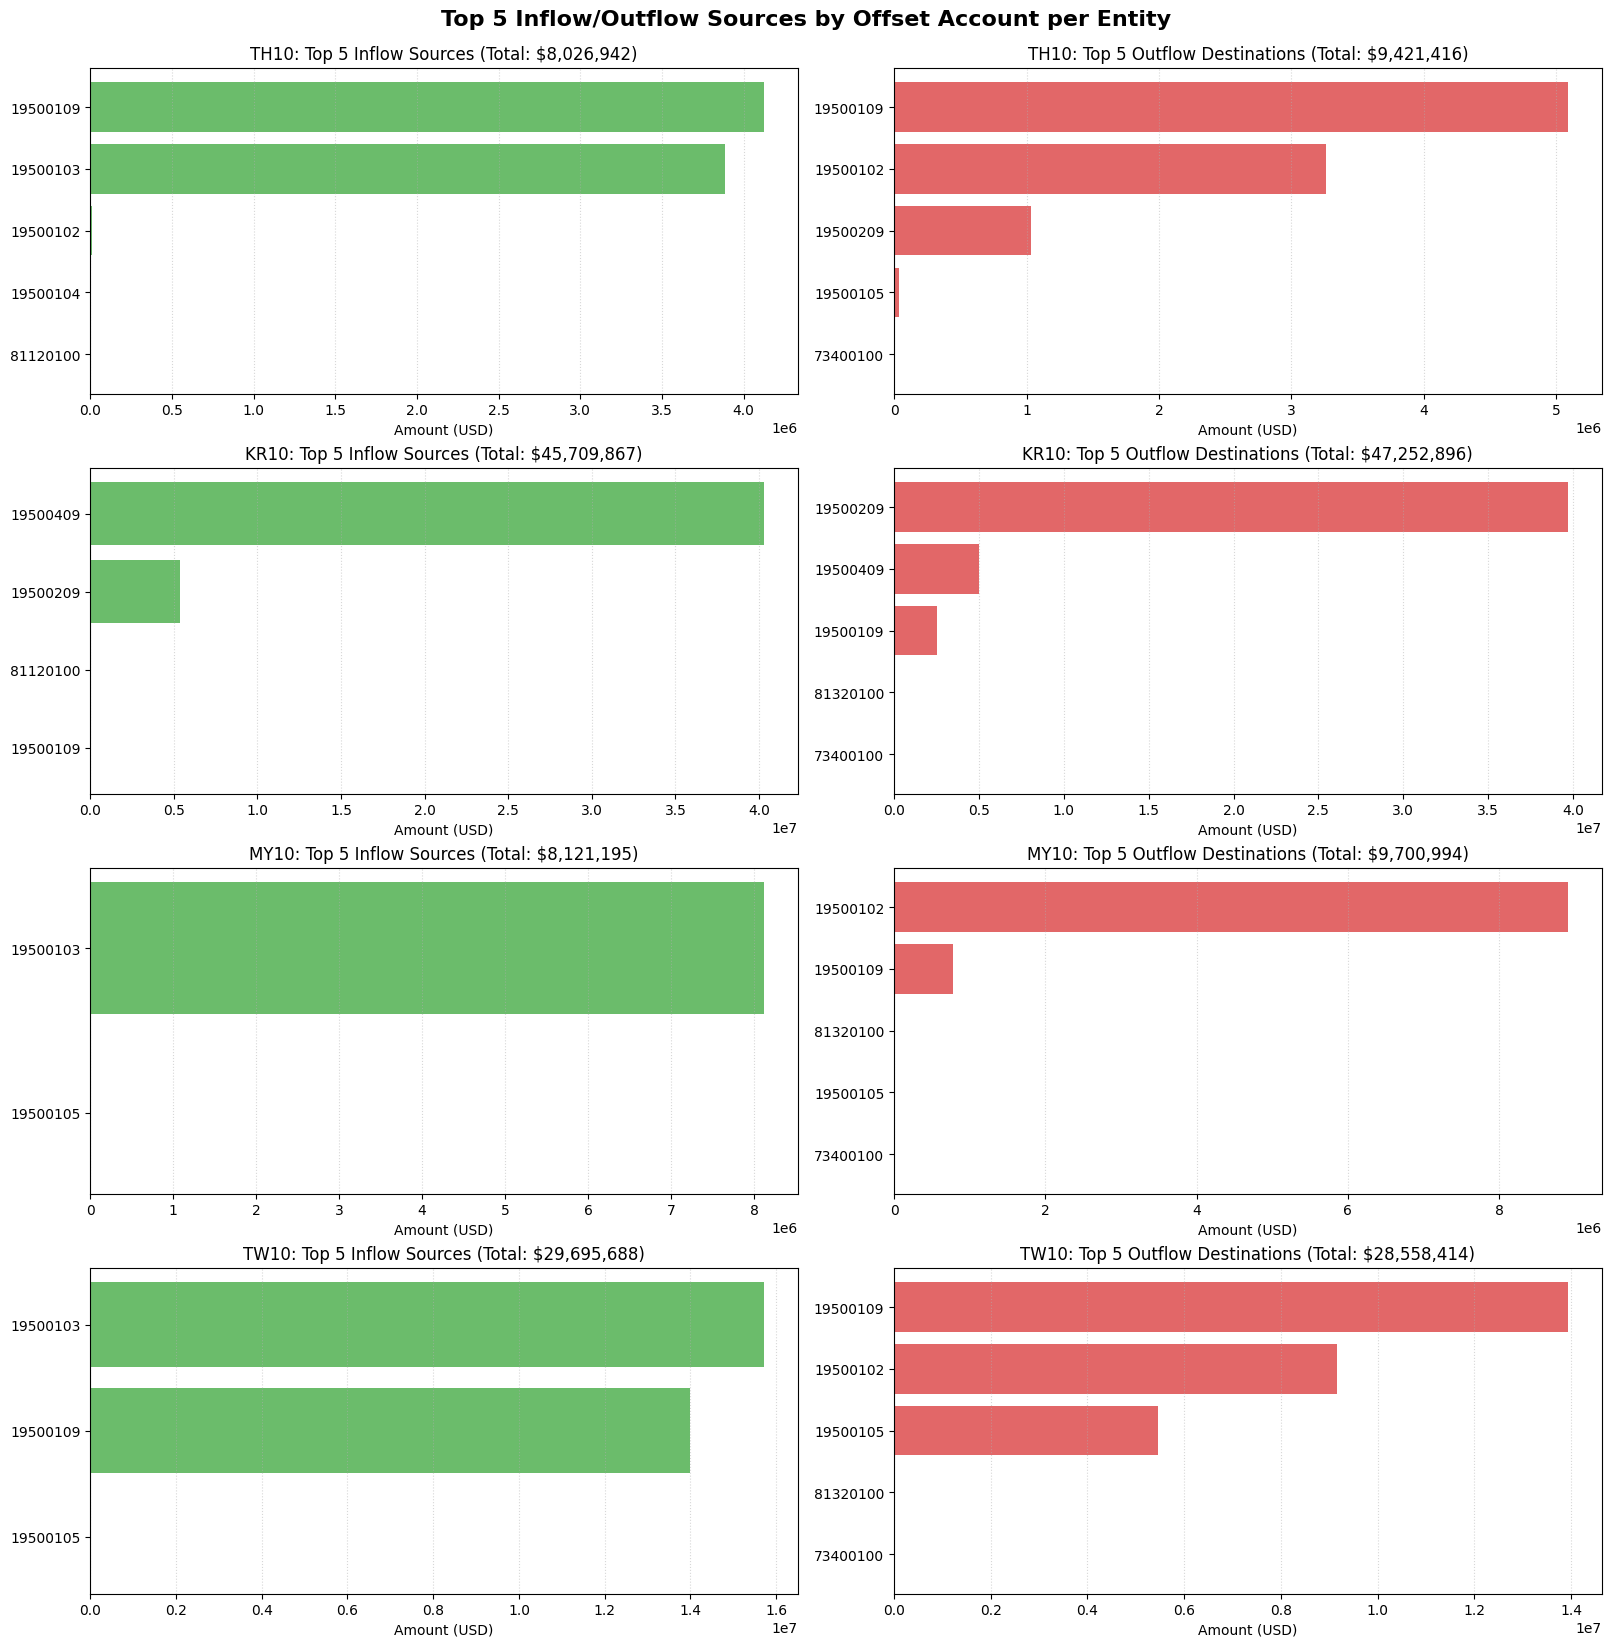

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare Data
# Convert Offst.acct to string to ensure it plots as a category, not a number
df['Offst.acct'] = df['Offst.acct'].astype(str)

# Define the entities for which we want to analyze top inflows/outflows
entities_to_analyze = ['TH10', 'KR10', 'MY10', 'TW10']

# 2. Plotting (4 rows x 2 columns for 4 entities x 2 charts each)
fig, axes = plt.subplots(len(entities_to_analyze), 2, figsize=(16, 4 * len(entities_to_analyze)), constrained_layout=True)

for i, entity_name in enumerate(entities_to_analyze):
    # Filter data for the current entity
    entity_df = df[df['Name'] == entity_name].copy()

    if not entity_df.empty:
        # Separate Inflow and Outflow for the current entity
        inflow_df = entity_df[entity_df['Amount in USD'] > 0].groupby('Offst.acct')['Amount in USD'].sum().sort_values()
        outflow_df = entity_df[entity_df['Amount in USD'] < 0].groupby('Offst.acct')['Amount in USD'].sum().abs().sort_values()

        # --- Chart for Inflow by Offset Account ---
        ax1 = axes[i, 0]
        if not inflow_df.empty:
            # Plot top 5
            top_inflow = inflow_df.tail(5)
            ax1.barh(top_inflow.index, top_inflow.values, color='tab:green', alpha=0.7)
            ax1.set_title(f'{entity_name}: Top 5 Inflow Sources (Total: ${inflow_df.sum():,.0f})')
            ax1.set_xlabel('Amount (USD)')
            ax1.grid(True, linestyle=':', alpha=0.5, axis='x')
        else:
            ax1.text(0.5, 0.5, 'No Inflows', ha='center', transform=ax1.transAxes)

        # --- Chart for Outflow by Offset Account ---
        ax2 = axes[i, 1]
        if not outflow_df.empty:
            # Plot top 5
            top_outflow = outflow_df.tail(5)
            ax2.barh(top_outflow.index, top_outflow.values, color='tab:red', alpha=0.7)
            ax2.set_title(f'{entity_name}: Top 5 Outflow Destinations (Total: ${outflow_df.sum():,.0f})')
            ax2.set_xlabel('Amount (USD)')
            ax2.grid(True, linestyle=':', alpha=0.5, axis='x')
        else:
            ax2.text(0.5, 0.5, 'No Outflows', ha='center', transform=ax2.transAxes)
    else:
        # If no data for the entity, mark both subplots as no data
        axes[i, 0].text(0.5, 0.5, f'No Data for {entity_name}', ha='center', transform=axes[i, 0].transAxes)
        axes[i, 1].text(0.5, 0.5, f'No Data for {entity_name}', ha='center', transform=axes[i, 1].transAxes)

plt.suptitle("Top 5 Inflow/Outflow Sources by Offset Account per Entity", fontsize=16, fontweight='bold', y=1.02)
plt.show()

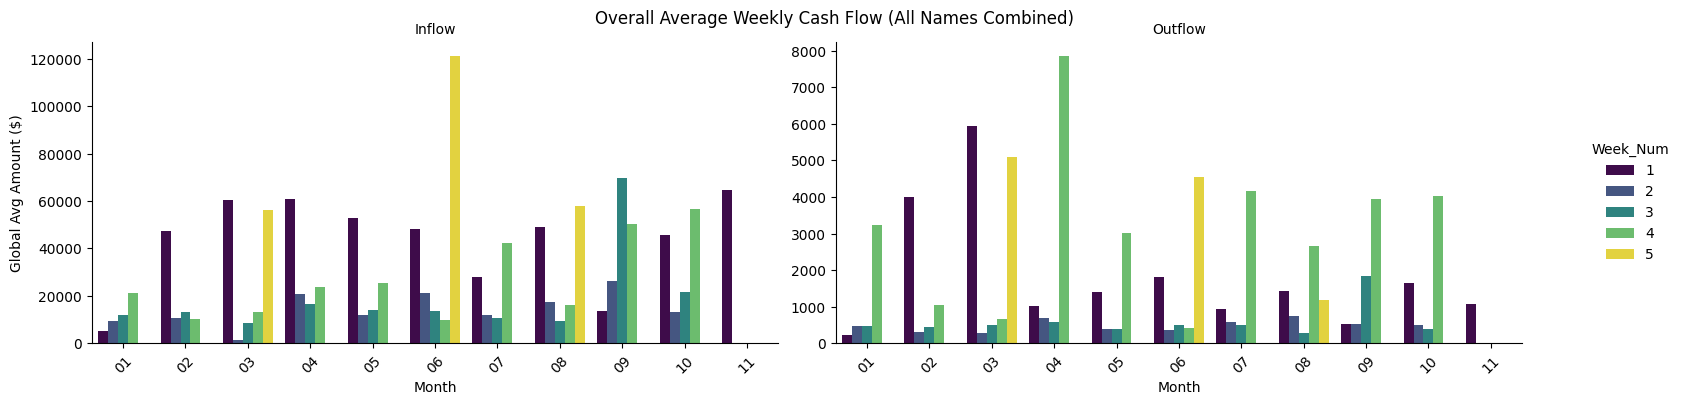

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Group WITHOUT 'Name' to get the global average
total_avg_df = (
    df.groupby(['Month', 'Week_Num', 'Flow_Label'])['Amount in USD']
    .mean()
    .abs()
    .reset_index()
)

# 2. Plot WITHOUT row="Name"
g = sns.catplot(
    data=total_avg_df,
    kind="bar",
    x="Month",
    y="Amount in USD",
    hue="Week_Num",
    col="Flow_Label",       # Keep Flow_Label separation
    # row="Name",           # REMOVED
    palette="viridis",
    height=4,               # Adjusted height for better visibility
    aspect=2,
    sharey=False,
    margin_titles=True
)

g.set_titles(col_template="{col_name}")
g.set_axis_labels("Month", "Global Avg Amount ($)")
g.set_xticklabels(rotation=45)

g.fig.subplots_adjust(top=0.90)
g.fig.suptitle("Overall Average Weekly Cash Flow (All Names Combined)")

plt.show()

In [83]:
import pandas as pd

df = pd.read_excel('/content/Datathoncleaned_data.xlsx')
df.head()

,Name,Account,PK,Offst.acct,Assignment,Pstng Date,Amount in USD,Posting Period,Category Index,Weekly_Period,Flow_Code
0,TW10,19500100,50,19500102,200021,2025-08-01,-13.85,2025-08,1,2025-08-W1,1
1,TW10,19500100,50,19500102,200021,2025-08-01,-15.81,2025-08,1,2025-08-W1,1
2,TW10,19500100,50,19500102,200021,2025-08-01,-14.99,2025-08,1,2025-08-W1,1
3,TW10,19500100,50,19500102,200021,2025-08-01,-11.90,2025-08,1,2025-08-W1,1
4,TW10,19500100,50,19500102,200021,2025-08-01,-15.16,2025-08,1,2025-08-W1,1


In [84]:
cols = ['Account', 'PK', 'Offst.acct', 'Assignment', 'Posting Period', 'Category Index']
df.drop(columns=cols, inplace=True, errors='ignore')
df.head()

,Name,Pstng Date,Amount in USD,Weekly_Period,Flow_Code
0,TW10,2025-08-01,-13.85,2025-08-W1,1
1,TW10,2025-08-01,-15.81,2025-08-W1,1
2,TW10,2025-08-01,-14.99,2025-08-W1,1
3,TW10,2025-08-01,-11.90,2025-08-W1,1
4,TW10,2025-08-01,-15.16,2025-08-W1,1


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84522 entries, 0 to 84521
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Name           84522 non-null  object        
 1   Pstng Date     84522 non-null  datetime64[ns]
 2   Amount in USD  84522 non-null  float64       
 3   Weekly_Period  84522 non-null  object        
 4   Flow_Code      84522 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [87]:
agg_config = {
    'transaction_count': ('Amount in USD', 'count'),
    'transaction_flow_mean': ('Amount in USD', 'mean'),
    'transaction_flow_total': ('Amount in USD', 'sum')
}

# Apply the aggregation configuration to the DataFrame
daily_summary_from_config = df.groupby(['Name', 'Pstng Date','Weekly_Period']).agg(**agg_config).reset_index()

print("Daily Summary created using agg_config:")
print(daily_summary_from_config.head())
daily_summary_from_config.info()

daily_summary_from_config.to_csv('Daily_Cash_Flow_With_Weekly_Column.csv', index=False)
print("File saved: 'Daily_Cash_Flow_With_Weekly_Column.csv'")


Daily Summary created using agg_config:
   Name Pstng Date Weekly_Period  transaction_count  transaction_flow_mean  \
0  ID10 2025-01-02    2025-01-W1                 36                 -87.72   
1  ID10 2025-01-03    2025-01-W1                 15                 -41.14   
2  ID10 2025-01-04    2025-01-W1                 44                -757.63   
3  ID10 2025-01-05    2025-01-W1                  2                  -7.31   
4  ID10 2025-01-06    2025-01-W2                 39                -526.33   

   transaction_flow_total  
0               -3,157.92  
1                 -617.14  
2              -33,335.86  
3                  -14.62  
4              -20,526.82  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1621 entries, 0 to 1620
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Name                    1621 non-null   object        
 1   Pstng Date              1621 non